# CSIS3764 Exam - Question 3
## Unsupervised Machine Learning on Cognac Dataset

In [2]:
# 3.1 Read cognac.csv into a dataframe named 'cognac'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

cognac = pd.read_csv('cognac.csv')
print("Dataset loaded successfully.")
print("Shape:", cognac.shape)
cognac.head()

Dataset loaded successfully.
Shape: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
# 3.2a Display last 10 records
print("=== Last 10 Records ===")
display(cognac.tail(10))

=== Last 10 Records ===


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
168,13.58,2.58,2.69,24.5,105,1.55,0.84,0.39,1.54,8.660000,0.74,1.80,750
169,13.40,4.60,2.86,25.0,112,1.98,0.96,0.27,1.11,8.500000,0.67,1.92,630
170,12.20,3.03,2.32,19.0,96,1.25,0.49,0.40,0.73,5.500000,0.66,1.83,510
171,12.77,2.39,2.28,19.5,86,1.39,0.51,0.48,0.64,9.899999,0.57,1.63,470
172,14.16,2.51,2.48,20.0,91,1.68,0.70,0.44,1.24,9.700000,0.62,1.71,660
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.700000,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.300000,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.200000,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.300000,0.60,1.62,840
177,14.13,4.10,2.74,24.5,96,2.05,0.76,0.56,1.35,9.200000,0.61,1.60,560


In [4]:
# 3.2b Concise summary: index, data type, columns, non-null values, memory usage
print("=== DataFrame Info ===")
cognac.info()

=== DataFrame Info ===
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [5]:
# 3.3 Unsupervised Learning — K-Means Clustering
# --- Pre-processing ---
print("=== Missing Values ===")
print(cognac.isnull().sum())

# All features are numeric — scale them
scaler = StandardScaler()
cognac_scaled = scaler.fit_transform(cognac)
print("\nAll features are numeric. Scaled with StandardScaler.")
print("Scaled shape:", cognac_scaled.shape)

=== Missing Values ===
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

All features are numeric. Scaled with StandardScaler.
Scaled shape: (178, 13)


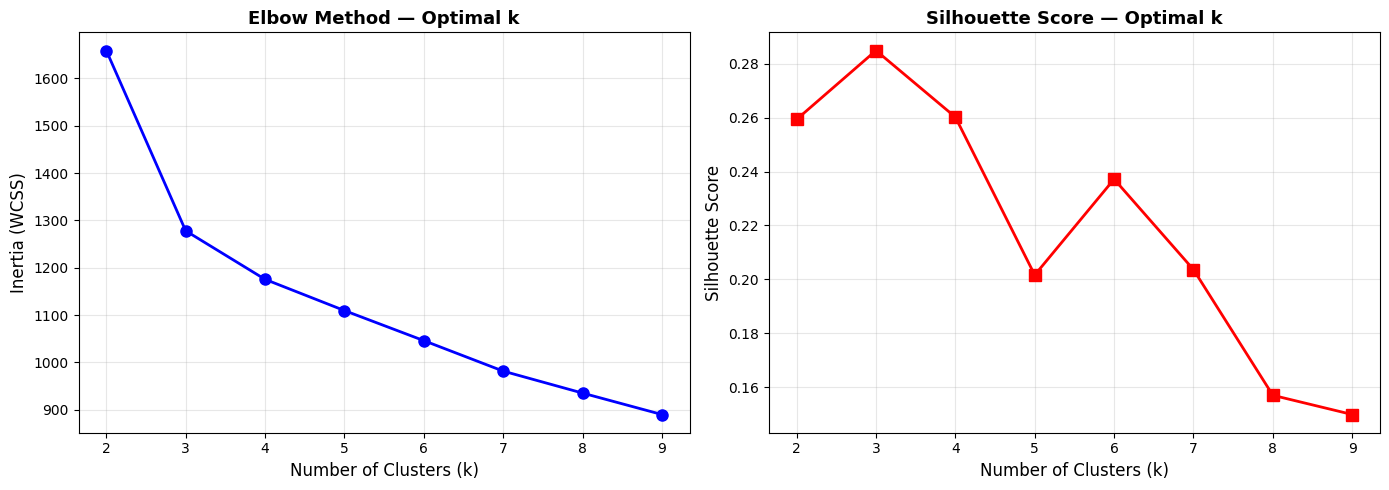


Based on the elbow in the inertia curve and highest silhouette score,
optimal k = 3


In [6]:
# Determine optimal k using Elbow Method and Silhouette Score
inertias = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cognac_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(cognac_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method — Optimal k', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score — Optimal k', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBased on the elbow in the inertia curve and highest silhouette score,")
print("optimal k =", list(K_range)[silhouettes.index(max(silhouettes))])

In [7]:
# Apply K-Means with optimal k=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cognac['Cluster'] = kmeans.fit_predict(cognac_scaled)

print("=== Cluster Labels ===")
print(cognac['Cluster'].values)

print("\n=== Cluster Distribution ===")
print(cognac['Cluster'].value_counts().sort_index())

=== Cluster Labels ===
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

=== Cluster Distribution ===
Cluster
0    65
1    51
2    62
Name: count, dtype: int64


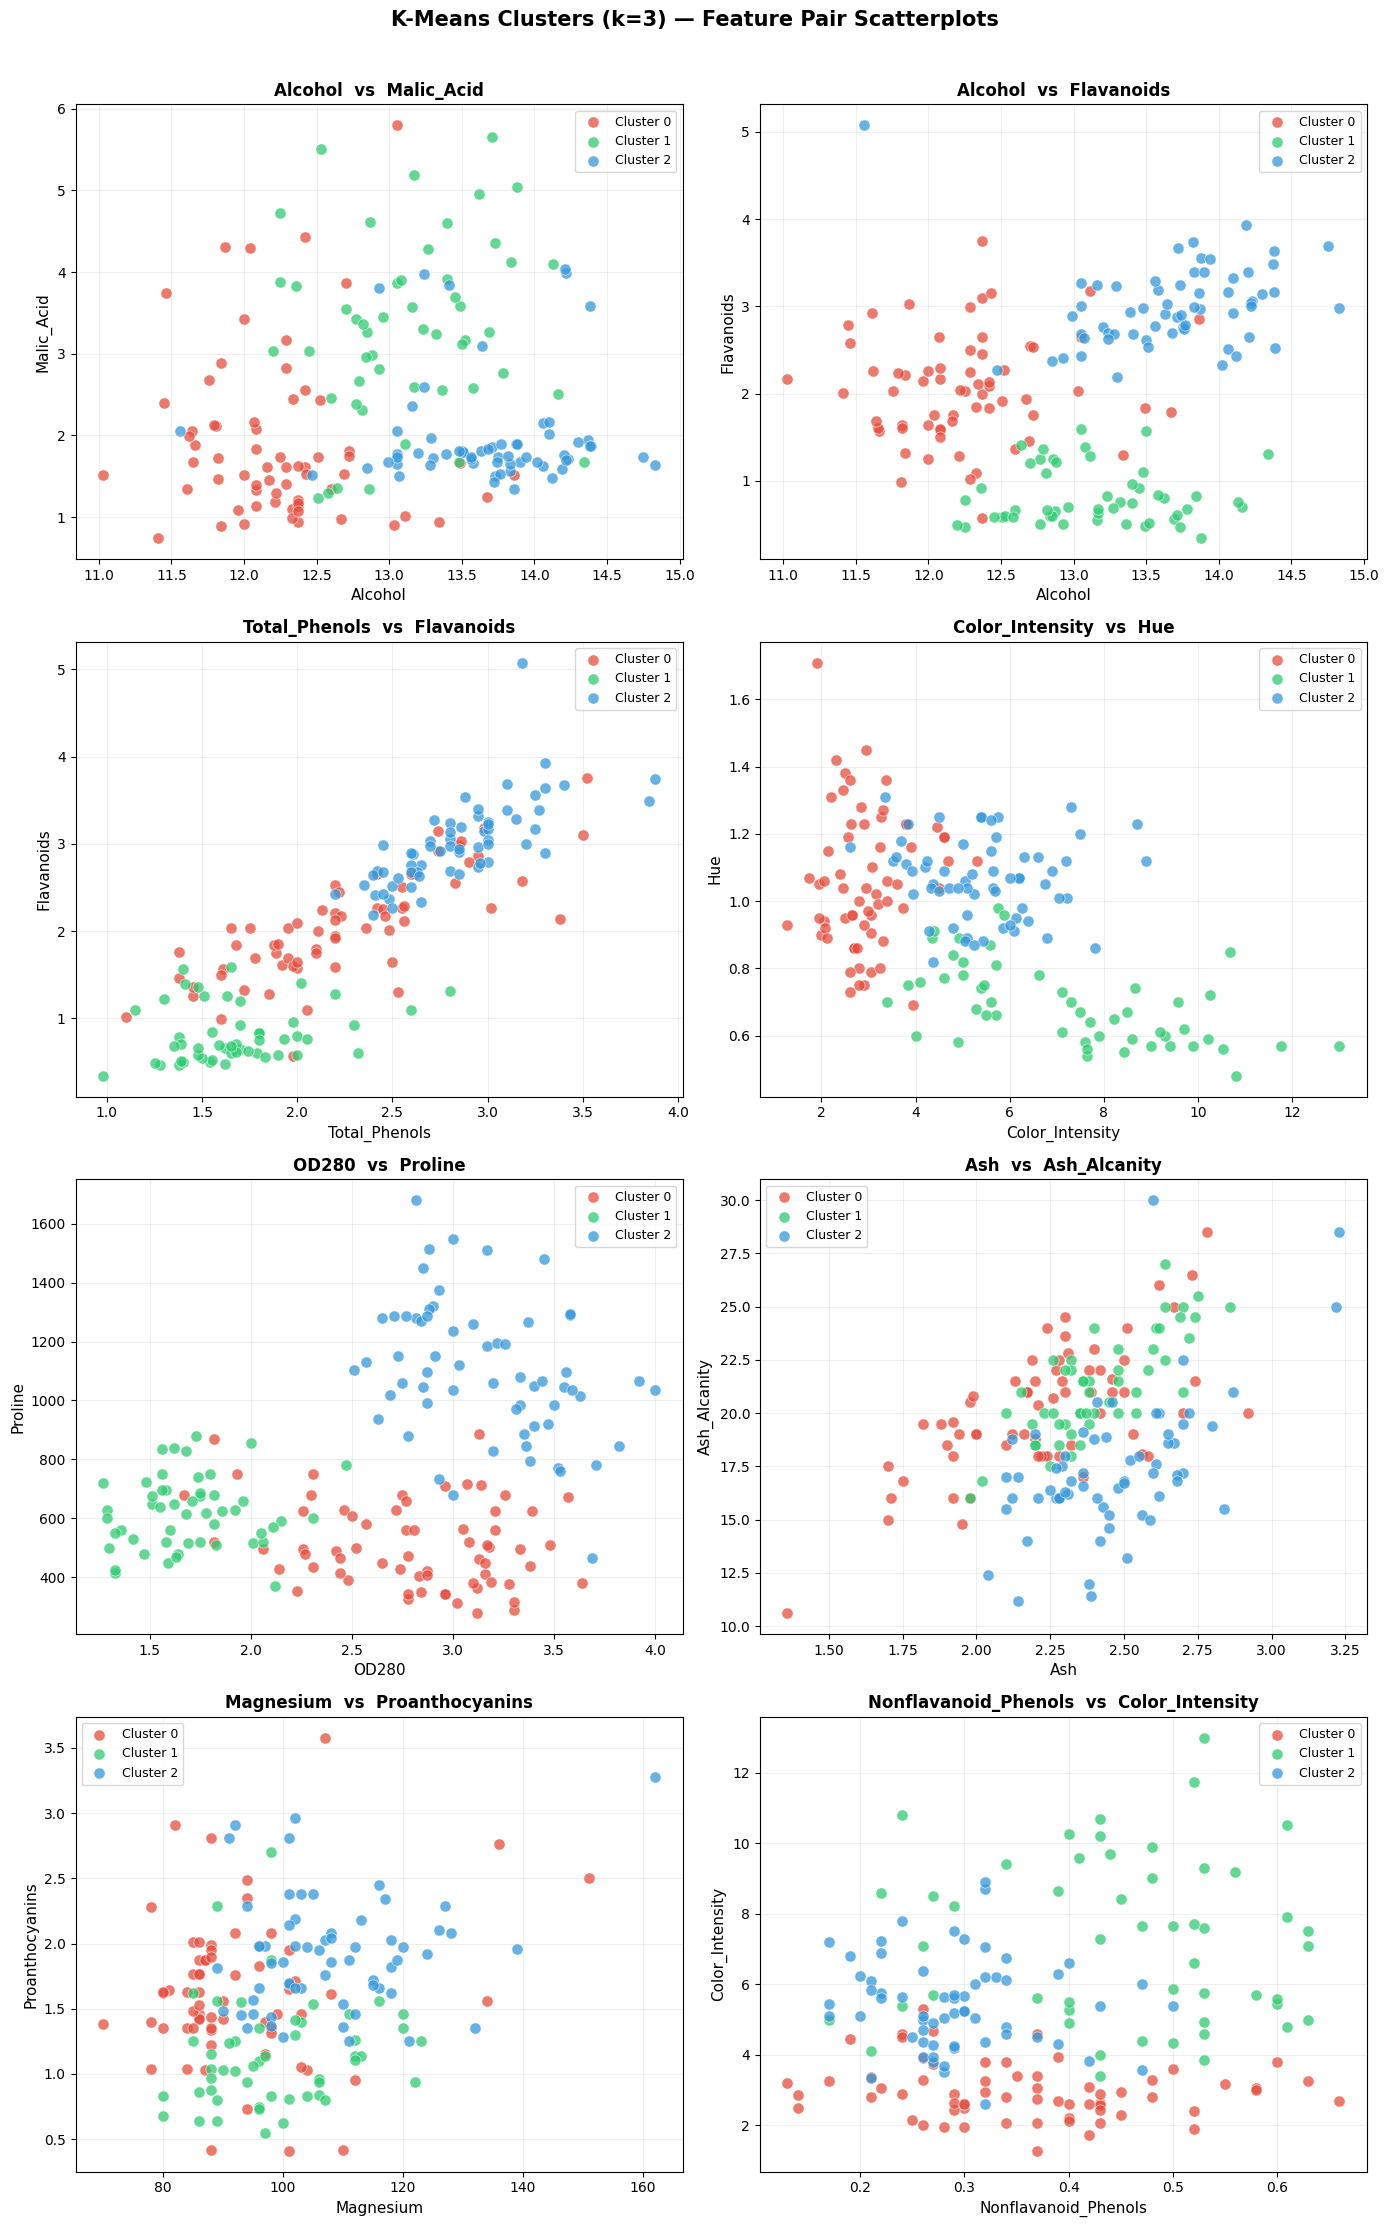

In [8]:
# 3.3 Extended: Scatterplots showing clusters for each key feature pair
palette = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}

pairs = [
    ('Alcohol', 'Malic_Acid'),
    ('Alcohol', 'Flavanoids'),
    ('Total_Phenols', 'Flavanoids'),
    ('Color_Intensity', 'Hue'),
    ('OD280', 'Proline'),
    ('Ash', 'Ash_Alcanity'),
    ('Magnesium', 'Proanthocyanins'),
    ('Nonflavanoid_Phenols', 'Color_Intensity'),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 22))
axes = axes.flatten()

for i, (fx, fy) in enumerate(pairs):
    for cl in sorted(cognac['Cluster'].unique()):
        sub = cognac[cognac['Cluster'] == cl]
        axes[i].scatter(sub[fx], sub[fy],
                        label=f'Cluster {cl}',
                        alpha=0.75, s=65,
                        color=palette[cl],
                        edgecolors='white', linewidth=0.5)
    axes[i].set_xlabel(fx, fontsize=11)
    axes[i].set_ylabel(fy, fontsize=11)
    axes[i].set_title(f'{fx}  vs  {fy}', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.2)

plt.suptitle('K-Means Clusters (k=3) — Feature Pair Scatterplots', fontsize=15, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# 3.4 Principal Component Analysis — reduce to 2 dimensions
X = cognac.drop(columns=['Cluster'])
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("=== Dimensions Before and After PCA ===")
print(f"Original dataset dimensions   : {X_scaled.shape}")
print(f"PCA-transformed dimensions    : {X_pca.shape}")

print("\n=== Principal Components (Feature Loadings) ===")
pc_df = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=['PC1', 'PC2'])
display(pc_df.round(4))

print("=== Explained Variance ===")
print(f"PC1 explained variance ratio : {pca.explained_variance_ratio_[0]:.4f}  ({pca.explained_variance_ratio_[0]*100:.1f}%)")
print(f"PC2 explained variance ratio : {pca.explained_variance_ratio_[1]:.4f}  ({pca.explained_variance_ratio_[1]*100:.1f}%)")
print(f"Total explained variance     : {pca.explained_variance_ratio_.sum():.4f}  ({pca.explained_variance_ratio_.sum()*100:.1f}%)")
print(f"\nExplained variance values    : {np.round(pca.explained_variance_, 4)}")

=== Dimensions Before and After PCA ===
Original dataset dimensions   : (178, 13)
PCA-transformed dimensions    : (178, 2)

=== Principal Components (Feature Loadings) ===


,PC1,PC2
Alcohol,0.1443,0.4837
Malic_Acid,-0.2452,0.2249
Ash,-0.0021,0.3161
Ash_Alcanity,-0.2393,-0.0106
Magnesium,0.1420,0.2996
Total_Phenols,0.3947,0.0650
Flavanoids,0.4229,-0.0034
Nonflavanoid_Phenols,-0.2985,0.0288
Proanthocyanins,0.3134,0.0393
Color_Intensity,-0.0886,0.5300


=== Explained Variance ===
PC1 explained variance ratio : 0.3620  (36.2%)
PC2 explained variance ratio : 0.1921  (19.2%)
Total explained variance     : 0.5541  (55.4%)

Explained variance values    : [4.7324 2.5111]


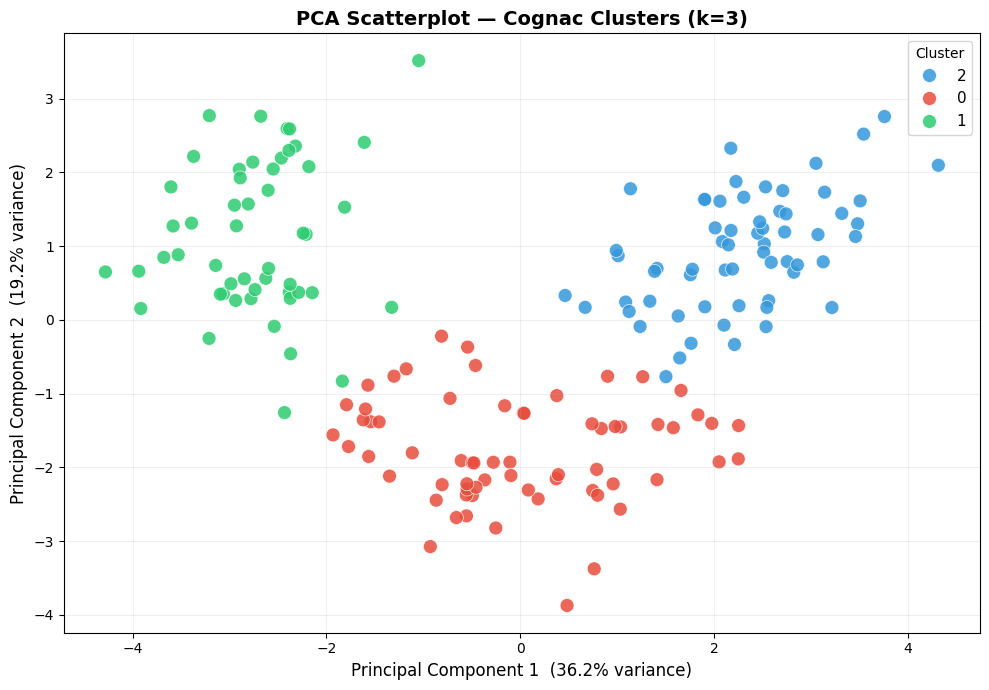

In [10]:
# Seaborn scatterplot of PCA components coloured by cluster
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cognac['Cluster'].astype(str)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='Cluster',
    palette={'0': '#e74c3c', '1': '#2ecc71', '2': '#3498db'},
    s=100, alpha=0.85, edgecolor='white', linewidth=0.5)
plt.title('PCA Scatterplot — Cognac Clusters (k=3)', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'Principal Component 2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.legend(title='Cluster', fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [11]:
# 3.5 Evaluate the scatter plot and discuss PCA effectiveness
print("""
=== 3.5 Discussion: Effectiveness of PCA Dimensionality Reduction ===

SCATTER PLOT EVALUATION:
The PCA scatter plot reduces the original 13-dimensional cognac dataset to 2 principal 
components, capturing approximately 55% of the total variance.

KEY OBSERVATIONS:

1. CLUSTER VISIBILITY: All three clusters identified by K-Means are distinguishable in 
   the 2D PCA space. Clusters 0 and 2 appear well-separated along the PC1 axis, while 
   Cluster 1 (green) tends to occupy an intermediate region.

2. SEPARATION QUALITY: The separation is reasonable but not perfect — some boundary 
   overlap exists between adjacent clusters. This is expected since 45% of variance 
   (residing in the discarded dimensions) is not represented in the 2D plot.

3. EFFECTIVENESS: PCA is moderately effective here. The fact that three chemically 
   distinct types of cognac can be visually distinguished with just 2 components out 
   of 13 original features suggests that the most important discriminating information 
   is concentrated in the first two principal components. This validates the clustering 
   solution and confirms that the chemical composition differences between cognac types 
   are systematic and meaningful.

4. LIMITATIONS: The ~45% unexplained variance means some cluster structure is invisible 
   in this 2D view. Using 3 or 4 PCA components would improve separability at the cost 
   of needing a 3D or multi-panel visualisation.

CONCLUSION: PCA provides a practical and informative dimensionality reduction for this 
dataset. The clusters are visually confirmable in 2D, supporting the validity of the 
K-Means solution while offering an easily interpretable visualisation.
""")


=== 3.5 Discussion: Effectiveness of PCA Dimensionality Reduction ===

SCATTER PLOT EVALUATION:
The PCA scatter plot reduces the original 13-dimensional cognac dataset to 2 principal 
components, capturing approximately 55% of the total variance.

KEY OBSERVATIONS:

1. CLUSTER VISIBILITY: All three clusters identified by K-Means are distinguishable in 
   the 2D PCA space. Clusters 0 and 2 appear well-separated along the PC1 axis, while 
   Cluster 1 (green) tends to occupy an intermediate region.

2. SEPARATION QUALITY: The separation is reasonable but not perfect — some boundary 
   overlap exists between adjacent clusters. This is expected since 45% of variance 
   (residing in the discarded dimensions) is not represented in the 2D plot.

3. EFFECTIVENESS: PCA is moderately effective here. The fact that three chemically 
   distinct types of cognac can be visually distinguished with just 2 components out 
   of 13 original features suggests that the most important discriminating in

```python(from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize your features (Critical first step!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Instantiate PCA (Let's reduce our data to 2 components)
pca = PCA(n_components=2)

# Fit and transform the data
X_pca = pca.fit_transform(X_scaled)

# Convert into a clean DataFrame
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

* Check how much information was preserved
print(f"Total Explained Variance: {sum(pca.explained_variance_ratio_)*100:.2f}%")